# Analysis of clustering results over all junctions
- length distribution of single core blocks and combined core blocks
- branch length cutoff selection based on branch length distribution
- distribution of pairwise distances between isolates as sanity check for branch length threshold selection and comparison to distances on tree
- distribution of number of clusters and relation to junction diversity for chosen cutoff of 0.001
- cluster consistency with block and edge structure
- further analysis of binary junctions to detect events that span several clusters and events associated with homologous recombinations
- length changes with homologous recombination events, restriced to junctions with exactly two clusters
- cluster consistency with core genome phylogeny

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt

import plotly.io as pio
pio.renderers.default = "browser" 

from junction_analysis.helpers import count_trna_per_junction, compute_within_between_cluster_distances, add_singleton_gain_loss_isolate_columns, add_singleton_has_own_cluster, add_binary_event_info, compare_consensus_paths, get_core_alignment_lengths
from junction_analysis.diversity_metrics import compute_dedup_ji_all_junctions
from junction_analysis.junction_trees import compute_pairwise_distances

from junction_analysis.plotting import plot_marginal_scatter, plot_cluster_count_distribution, plot_cluster_count_vs_diversity, plot_pairwise_distance_hist, plot_path_comparison_lengths
from junction_analysis.plotting import plot_all_junctions_pairwise_distances, plot_all_junctions_pairwise_distances_zoom, plot_score_threshold_violin, plot_core_alignment_lengths
from junction_analysis.consensus import find_consensus_paths_core, collect_all_branch_lengths, fitch_parsimony_steps_per_cluster, collect_all_pairwise_distances
from junction_analysis.annotate_insertions import combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

## Summarize results

In [3]:
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

# summarize results
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
trna_counts_df = count_trna_per_junction(annotations_dir="../results/junction_annotations",
    category_bins=[-1, 0, 50, 300, float("inf")], category_labels=["0", "1–50", "50–300", ">300"],)
summaries = combine_all_junctions_summaries("../results/atb_lookup", save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path="../results/atb_lookup/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path="../results/atb_lookup/event_counts_per_junction.csv")

jdf_trna = jdf.copy().merge(trna_counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                 
jdf_clusters = jdf_trna.merge(cluster_df[["junction_name", "n_clusters"]].set_index("junction_name"), left_on="edge", right_index=True, how="left")

jdf_all = jdf_clusters.merge(counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                                                                                                              
jdf_all[counts_df.columns.drop("junction_name")] = jdf_all[counts_df.columns.drop("junction_name")].fillna(0)

jdf_all.rename(columns={"edge": "junction_name"}, inplace=True)

# only continue with junctions that have at least 2 different paths, otherwise they are not junctions (could happen because of duplications to elsewhere or syntheny breaks) 
jdf_all = jdf_all[jdf_all["n_categories"] >= 2]
# for now don't filter out junctions with only very few isolates, but might generally make sense to do so

jdf_hotspot = jdf_all[jdf_all["n_categories"] > 2]
jdf_nonsingleton = jdf_all[jdf_all["singleton"] == False]
jdf_binary = jdf_all[jdf_all["n_categories"] == 2]
jdf_singleton = jdf_binary[jdf_binary["singleton"] == True]
jdf_binary_nonsingleton = jdf_binary[jdf_binary["singleton"] == False]

nonbinary_junctions = jdf_all[jdf_all['n_categories'] > 2].junction_name.tolist()                                                                                                                                                                                                                                                                               
summary_df_nb = deduplicated_events_df[deduplicated_events_df['junction_name'].isin(nonbinary_junctions)]

Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved ambiguous_insertions summary to ../results/atb_lookup/insertions/all_junctions_ambiguous_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup/deduplicated_events.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


In [9]:
# alternatively read presaved results
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

## Core block length distribution

In [ ]:
core_aln_length_df, core_block_aln_length_df = get_core_alignment_lengths(
    consensus_analysis_dir="../results/consensus_analysis",
    results_dir="../results",
    save_path="../results/consensus_analysis/core_aln_lengths.csv",
    block_save_path="../results/consensus_analysis/core_block_aln_lengths.csv",
)

# 5 min

Saved figure to ../figures/core_block_length_distr.pdf


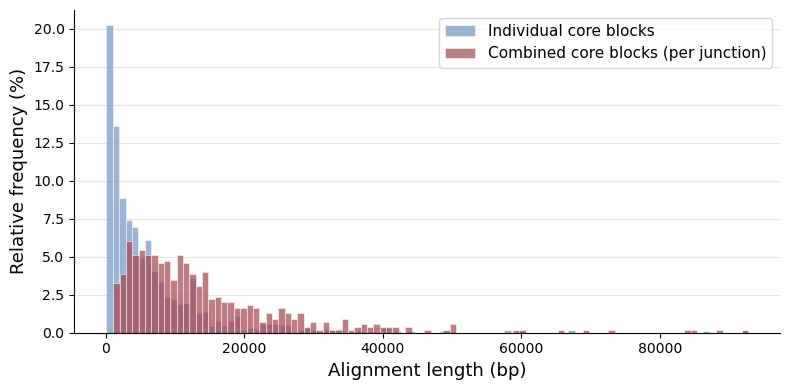

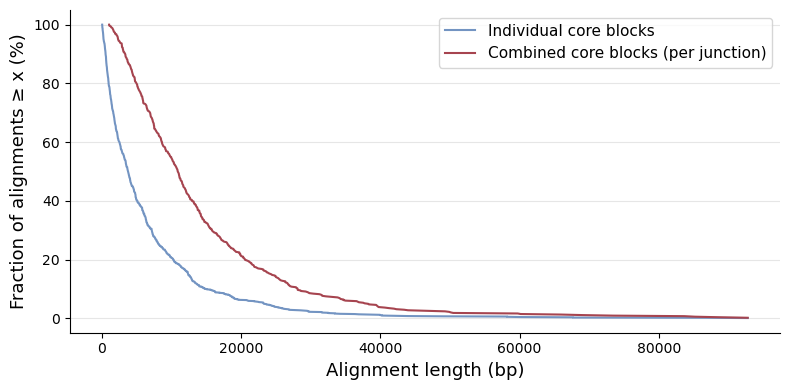

In [ ]:
core_aln_length_df = pd.read_csv("../results/consensus_analysis/core_aln_lengths.csv")
core_block_aln_length_df = pd.read_csv("../results/consensus_analysis/core_block_aln_lengths.csv")

plot_core_alignment_lengths(core_aln_length_df, block_df=core_block_aln_length_df, col="aln_length_nogap", bins=100, cumulative=False, figsize=(8,4), save_path="../figures/core_block_length_distr.pdf")
plot_core_alignment_lengths(core_aln_length_df, block_df=core_block_aln_length_df, col="aln_length_nogap", cumulative=True, figsize=(8,4)) 

## Cutoff selection considering branch length distribution

Saved branch lengths to ../results/consensus_analysis/branch_lengths.csv.


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:4505: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



Saved figure to ../figures/branch_length_cutoff.pdf


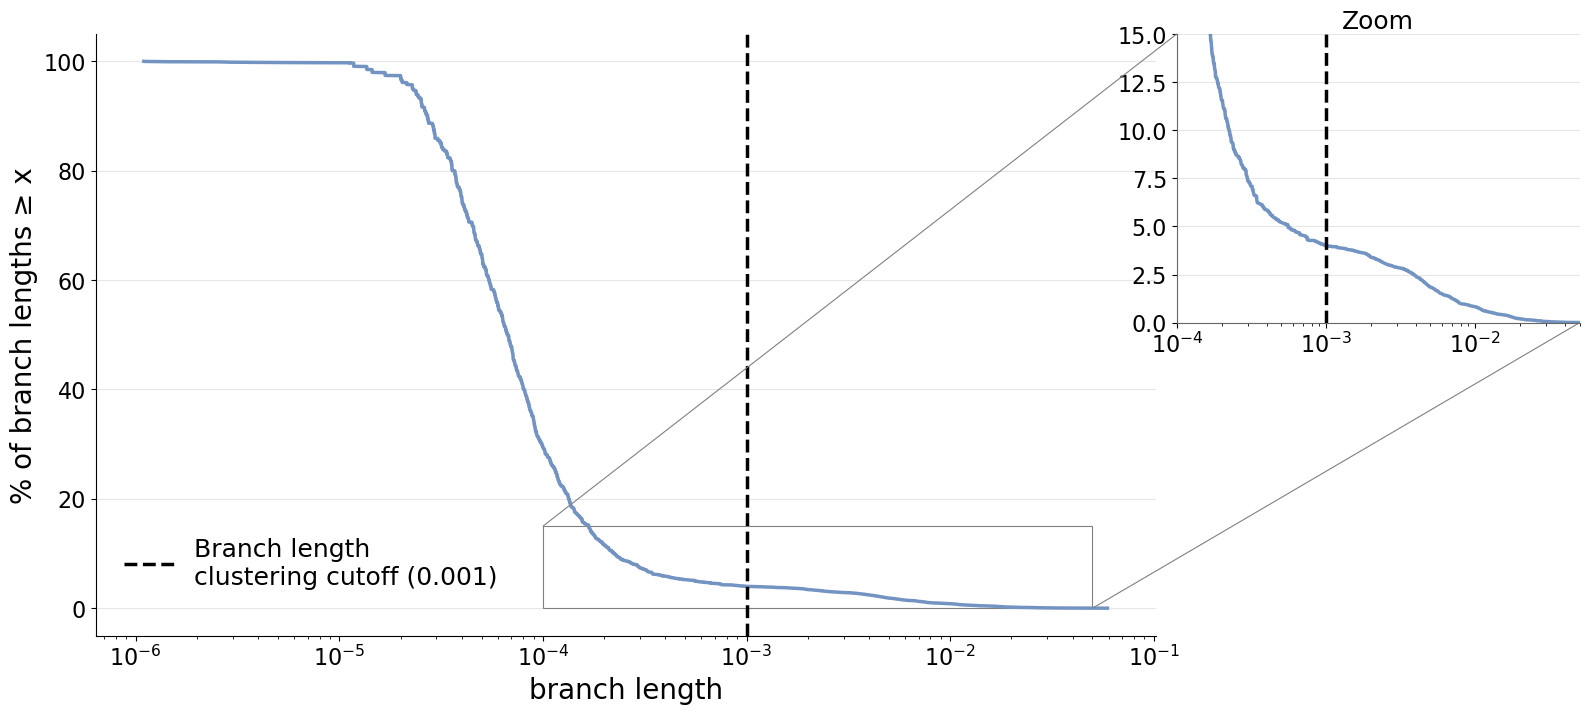

In [7]:
branch_df = collect_all_branch_lengths("../results/", save_path="../results/consensus_analysis/branch_lengths.csv")
bl_cutoff = 0.001

plot_all_junctions_pairwise_distances_zoom(
    distances_df=branch_df[branch_df['branch_length']>1e-8],
    distance_col='branch_length',
    cumulative=True,
    percentage=True,
    log_x=True,
    vline=bl_cutoff,
    figsize=(12, 7),
    title="",
    xlabel="branch length",
    ylabel="% of branch lengths ≥ x",
    legend_title="Branch length \nclustering cutoff (0.001)",
    zoom_xlim=(1e-4, 5e-2),
    zoom_ylim=(0, 15),
    save_path="../figures/branch_length_cutoff.pdf"
)

## Distribution of relative pairwise hamming distances between core blocks including all junctions

In [ ]:
alignment_dist_df = collect_all_pairwise_distances(junction_names=jdf.edge.tolist(), results_dir="../results/", save_path="../results/consensus_analysis/pairwise_rel_hamming_dist.csv")

# 20 min

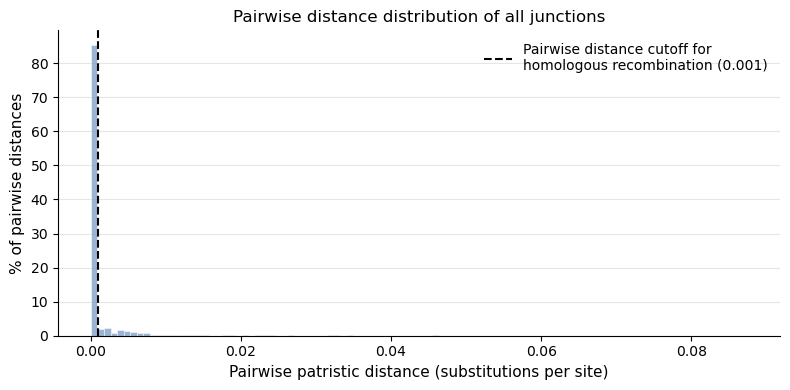

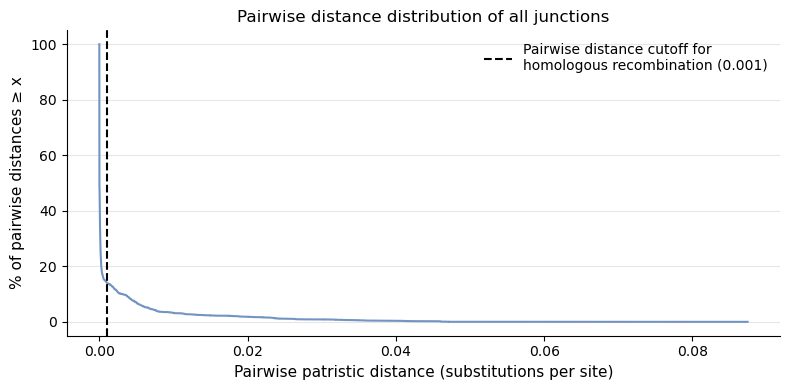

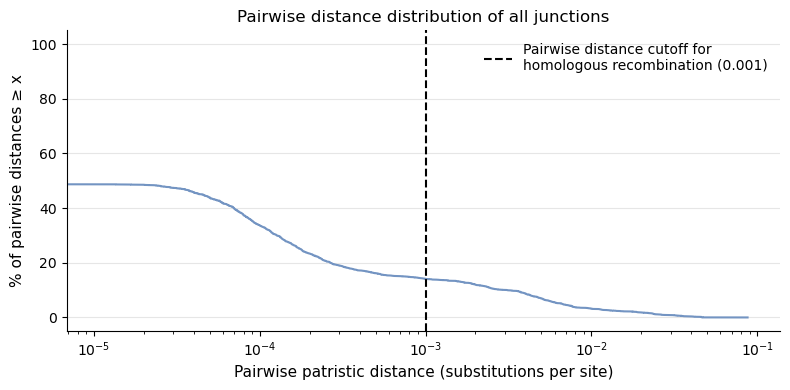

In [ ]:
# Load instead of recomputing
alignment_dist_df = pd.read_csv("../results/consensus_analysis/pairwise_rel_hamming_dist.csv")

# Plot, optionally excluding some junctions
plot_all_junctions_pairwise_distances(alignment_dist_df, vline=0.001, percentage=True, title="Pairwise distance distribution of all junctions", figsize=(8,4))
plot_all_junctions_pairwise_distances(alignment_dist_df, cumulative=True, vline=0.001, percentage=True, title="Pairwise distance distribution of all junctions", figsize=(8,4))
plot_all_junctions_pairwise_distances(alignment_dist_df, cumulative=True, log_x=True, vline=0.001, percentage=True, title="Pairwise distance distribution of all junctions", figsize=(8,4))

Comparison to pairwise distances on tree. These are calculated based on branch lengths in core genome tree.

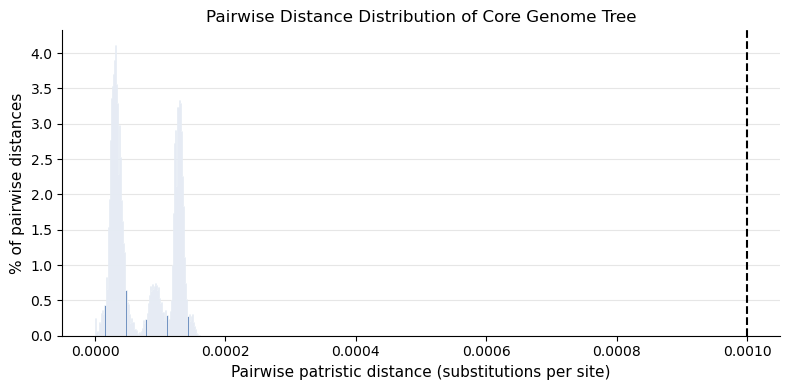

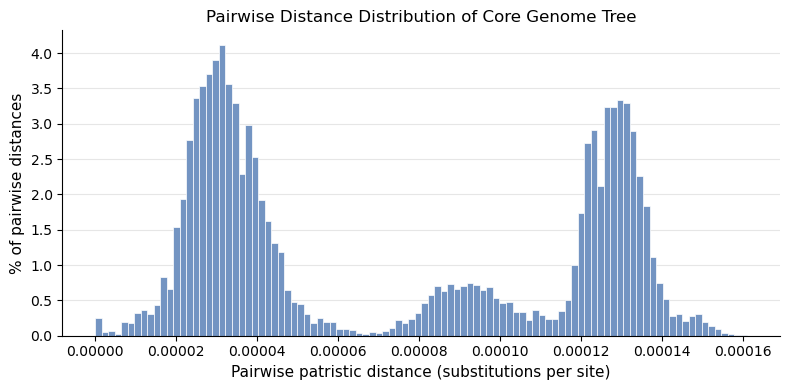

In [ ]:
# based on distances on tree, potentially recompute with hamming distance (collect_all_pairwise_distances)

dists = compute_pairwise_distances('../config/polished_tree.nwk')
plot_pairwise_distance_hist(dists, bins=100, vline=0.001, vline_kwargs={"color": "black", "linestyle": "--"}, title="Pairwise Distance Distribution of Core Genome Tree", figsize=(8,4), percentage=True)
plot_pairwise_distance_hist(dists, bins=100, vline=None, vline_kwargs={"color": "black", "linestyle": "--"}, title="Pairwise Distance Distribution of Core Genome Tree", figsize=(8,4), percentage=True)

## Distribution of number of clusters and relation to junction diversity for chosen cutoff of 0.001

Saved figure to ../figures/n_cluster_distr.pdf


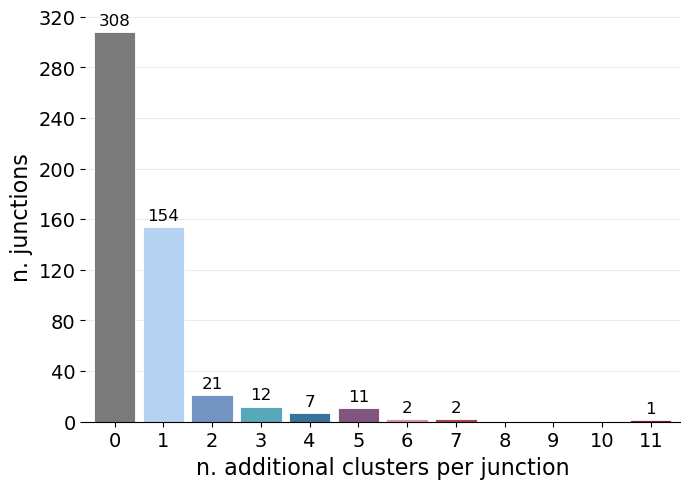

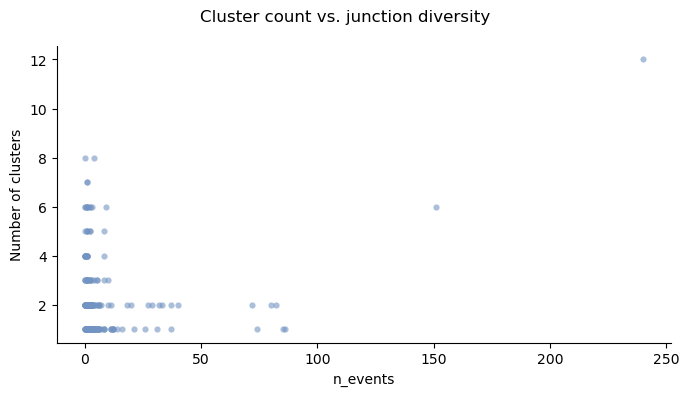

Saved figure to ../figures/n_cluster_junction_diversity.pdf


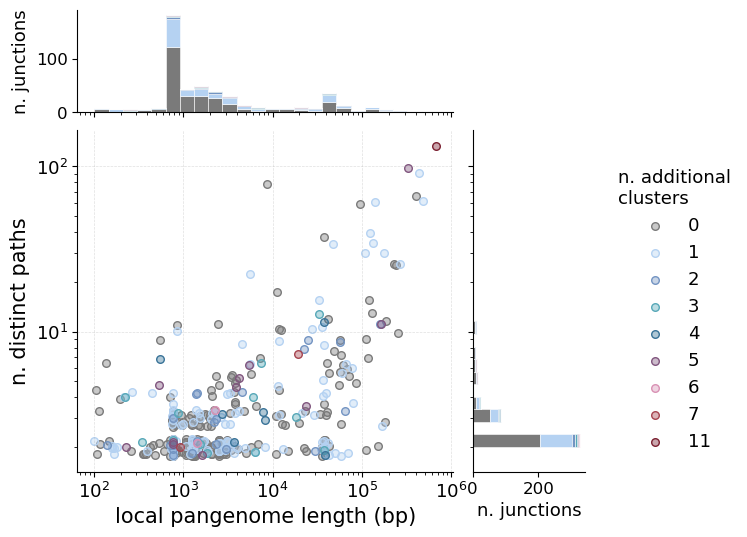

In [9]:
# visualize the number of observed clusters, compare them to the number of secondary events and set them in the context of j

plot_cluster_count_distribution(jdf_all, (7,5), save_path=("../figures/n_cluster_distr.pdf"))
plot_cluster_count_vs_diversity(jdf_all, diversity_columns=["n_events"], figsize=(7,4))

fig, axes = plot_marginal_scatter(
    jdf_all,
    x_col="tot_acc_len",
    y_col="n_categories",
    y_jitter_low=0.88,
    y_jitter_high=1.12,
    fill_alpha=0.4,
    edge_alpha=1,
    scatter_size=30,
    random_seed=42,
    point_linewidth=1,
    color_by_n_clusters=True,
    filter_y_gt_1 = True,
    filled = True,
    save_path="../figures/n_cluster_junction_diversity.pdf"
)
plt.show()

## Cluster consistency with block and edge structure
- validate clustering by calculating within- and betweem distance for each isolate in clustered junctions based on Jaccard index of block and edge presence or absence 
- calculate silhouette scores to check clustering based on these jaccard indices
- just to have a quick additional validation, we also calculate within- and between distances of clusters based on pairwise distances, as expected they lead to generally big silhouette scores

In [2]:
# calculate block and edge jaccard index between all isolate pairs for all junctions
pairwise_df = compute_dedup_ji_all_junctions(                                                                                                                                                             
    pangraph_dir="../results/junction_pangraphs",                                                                                                                                                       
    save_path="../results/consensus_analysis/pairwise_dedup_ji.csv",                                                                                                                                      
)

Saved to ../results/consensus_analysis/pairwise_dedup_ji.csv


In [3]:
alignment_dist_df = pd.read_csv("../results/consensus_analysis/pairwise_rel_hamming_dist.csv")

block_edge_dist = pd.read_csv("../results/consensus_analysis/pairwise_dedup_ji.csv")

# transfrom jaccard similarity into distance with 1 - J
block_dist_df = block_edge_dist.copy().loc[:, ['junction_name', 'isolate_1', 'isolate_2', 'block_ji_dist']]
block_dist_df['block_ji_dist'] = 1 - block_dist_df['block_ji_dist']
block_dist_df.rename(columns={'block_ji_dist': 'distance'}, inplace=True)

edge_dist_df = block_edge_dist.copy().loc[:, ['junction_name', 'isolate_1', 'isolate_2', 'edge_ji_dist']]
edge_dist_df['edge_ji_dist'] = 1 - edge_dist_df['edge_ji_dist']
edge_dist_df.rename(columns={'edge_ji_dist': 'distance'}, inplace=True)

In [8]:
for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    print(thresh)
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    wb_cluster_dist = compute_within_between_cluster_distances(cluster_df, alignment_dist_df, save_path=f'../results/consensus_analysis/cluster_pairwise_dist_000{thresh}.csv')

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    print(thresh)
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    wb_cluster_dist = compute_within_between_cluster_distances(cluster_df, block_dist_df, save_path=f'../results/consensus_analysis/cluster_block_ji_000{thresh}.csv')

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    print(thresh)
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    wb_cluster_dist = compute_within_between_cluster_distances(cluster_df, edge_dist_df, save_path=f'../results/consensus_analysis/cluster_edge_ji_000{thresh}.csv')

# 181 min

05
1
2
3
4
5
6
05
1
2
3
4
5
6
05
1
2
3
4
5
6


In [10]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

core_pairwise_paths = [f"../results/consensus_analysis/cluster_pairwise_dist_000{thresh}.csv" for thresh in ['05', '1', '2', '3', '4', '5', '6']]
block_paths = [f"../results/consensus_analysis/cluster_block_ji_000{thresh}.csv" for thresh in ['05', '1', '2', '3', '4', '5', '6']]
edge_paths = [f"../results/consensus_analysis/cluster_edge_ji_000{thresh}.csv" for thresh in ['05', '1', '2', '3', '4', '5', '6']]

# maybe need to compare clustering between junctions that have clusters in all cases but more or less, this is done now
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_006.csv")
clustering_exists = cluster_df[(cluster_df['n_clusters'] > 1) & (cluster_df.junction_name.isin(jdf_all.junction_name.to_list()))].junction_name.to_list()

wb_core_pairwise_dfs = []
wb_block_dfs = []
wb_edge_dfs = []

for path in core_pairwise_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = (
        wb_diff_df
        .groupby("junction_name")[["a", "b", "silhouette"]]
        .mean()
        .reset_index()
    )
    wb_core_pairwise_dfs.append(wb_diff_df)

for path in block_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = (
        wb_diff_df
        .groupby("junction_name")[["a", "b", "silhouette"]]
        .mean()
        .reset_index()
    )
    wb_block_dfs.append(wb_diff_df)

for path in edge_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = (
        wb_diff_df
        .groupby("junction_name")[["a", "b", "silhouette"]]
        .mean()
        .reset_index()
    )
    wb_edge_dfs.append(wb_diff_df)

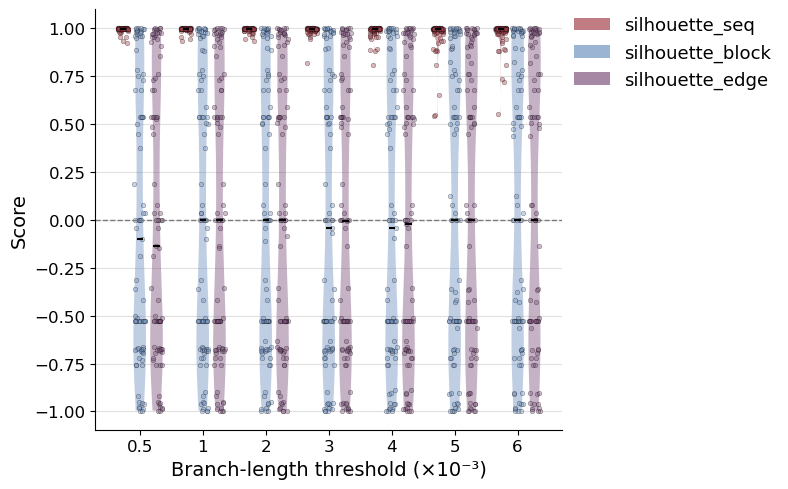

Saved figure to ../figures/silhouette_block_edge_ji.pdf
median block_silhouette: -0.10130109343004678
median edge_silhouette: -0.13924410622523825
median block_silhouette: 0.0
median edge_silhouette: 0.0
median block_silhouette: 0.0
median edge_silhouette: 0.0
median block_silhouette: -0.04090909090909091
median edge_silhouette: -0.007801741103813582
median block_silhouette: -0.04090909090909091
median edge_silhouette: -0.023491300134865927
median block_silhouette: 0.0
median edge_silhouette: 0.0
median block_silhouette: 0.0
median edge_silhouette: 0.0


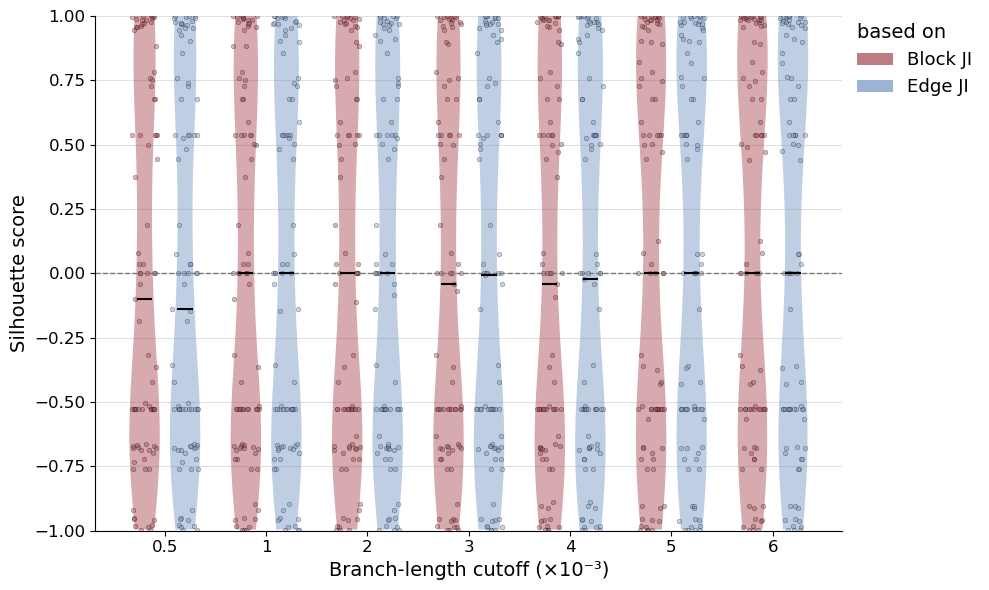

In [11]:
combined_dfs = [
      core.rename(columns={"silhouette": "silhouette_seq"})[["junction_name", "silhouette_seq"]]
      .merge(block.rename(columns={"silhouette": "silhouette_block"})[["junction_name", "silhouette_block"]], on="junction_name", how="outer")                                                        
      .merge(edge.rename(columns={"silhouette": "silhouette_edge"})[["junction_name", "silhouette_edge"]], on="junction_name", how="outer")
      for core, block, edge in zip(wb_core_pairwise_dfs, wb_block_dfs, wb_edge_dfs)                                                                                                                         
  ]
plot_score_threshold_violin(combined_dfs, thresholds=[0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006],
      score_col=["silhouette_seq", "silhouette_block", "silhouette_edge"])

plot_score_threshold_violin(combined_dfs, thresholds=[0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006],
      score_col=["silhouette_block", "silhouette_edge"], ylim = (-1,1), figsize=(10,6), xlabel = "Branch-length cutoff" , ylabel = "Silhouette score", legend_labels=["Block JI", "Edge JI"], legend_title = "based on", save_path = "../figures/silhouette_block_edge_ji.pdf")

for df in combined_dfs:
    print(f"median block_silhouette: {df.silhouette_block.median()}")
    print(f"median edge_silhouette: {df.silhouette_edge.median()}")

We now also have a closer look at the chosen threshold 0.001, checking how including different junction complexities effects silhouette scores.

Saved figure to ../figures/silhouette_junction_complexity.pdf


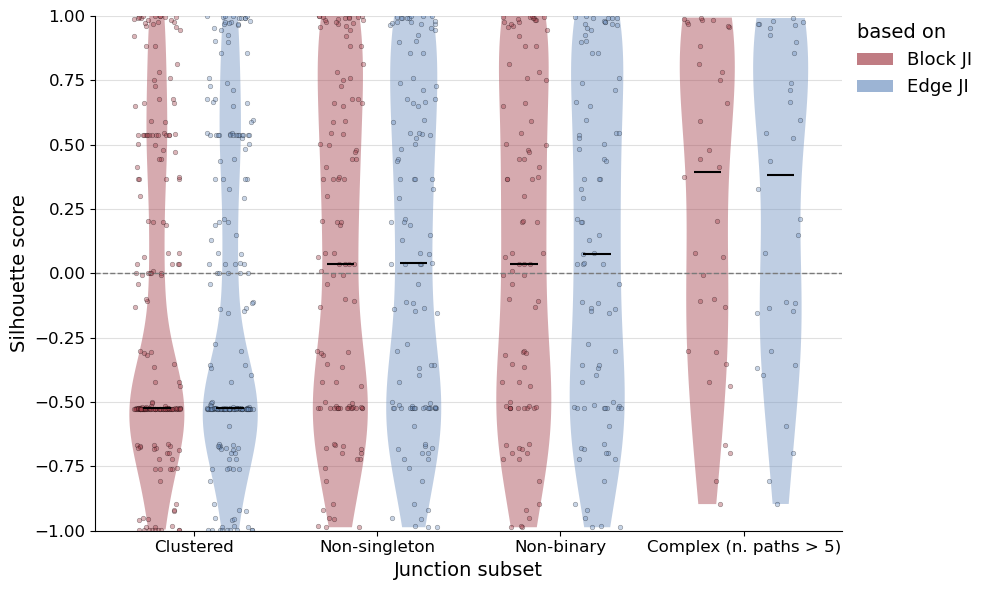

In [12]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")


# load only threshold 0.001            
core_df_001 = pd.read_csv("../results/consensus_analysis/cluster_pairwise_dist_0001.csv")
block_df_001 = pd.read_csv("../results/consensus_analysis/cluster_block_ji_0001.csv")                                                                                                                     
edge_df_001 = pd.read_csv("../results/consensus_analysis/cluster_edge_ji_0001.csv")
                                                                                                                                                                                                        
# filtering lists
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
non_singletons = jdf[jdf['singleton'] == False].edge.to_list()
non_binary = jdf[jdf['n_categories'] > 2].edge.to_list()
complex_junctions = jdf[jdf['n_categories'] > 5].edge.to_list()
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_001.csv")
clustering_exists = cluster_df[(cluster_df['n_clusters'] > 1) & cluster_df.junction_name.isin(jdf_all.junction_name.to_list())].junction_name.to_list()


filter_sets = {
    "Clustered":      clustering_exists,
    "Non-singleton":     [j for j in clustering_exists if j in non_singletons],
    "Non-binary":         [j for j in clustering_exists if j in non_binary],
    "Complex (n. paths > 5)":   [j for j in clustering_exists if j in complex_junctions],
}

def make_combined_df(junctions):
    def prep(df, score_col_name, is_similarity):
        d = df[df["junction_name"].isin(junctions)].copy()
        d = (
            d
            .groupby("junction_name")[["a", "b", "silhouette"]]
            .mean()
            .reset_index()
        )
        return d.rename(columns={"silhouette": score_col_name})[["junction_name", score_col_name]]
    core  = prep(core_df_001,  "silhouette_seq",   is_similarity=False)
    block = prep(block_df_001, "silhouette_block",  is_similarity=True)
    edge  = prep(edge_df_001,  "silhouette_edge",   is_similarity=True)
    return core.merge(block, on="junction_name", how="outer").merge(edge, on="junction_name", how="outer")

filter_dfs = [make_combined_df(junctions) for junctions in filter_sets.values()]

plot_score_threshold_violin(
    filter_dfs,
    thresholds=list(filter_sets.keys()),
    score_col=["silhouette_block", "silhouette_edge"],
    ylim=(-1, 1),
    figsize=(10, 6),
    xlabel="Junction subset",
    ylabel="Silhouette score",
    legend_labels=["Block JI", "Edge JI"],
    legend_title="based on",
    save_path="../figures/silhouette_junction_complexity.pdf"
)


## Are structural events in binary junctions associated with homolgous recombinations and consistant with clustering
Restrict analysis to binary junctions (only containing two alternative paths), first singleton and then non-singleton junctions.

Among singleton junctions, only 6 of 273 events (2\%) were associated with homologous recombination. In contrast, among non-singleton junctions, 8 of 49 events (16\%) were confined to a single cluster. One of these corresponded to a combined gain-and-loss event, a category observed three times among non-singleton junctions.

In [ ]:
jdf_all = add_singleton_gain_loss_isolate_columns(jdf_all, pangraph_dir="../results/junction_pangraphs")
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
jdf_all = add_singleton_has_own_cluster(jdf_all, cluster_df)
# 31.35s
jdf_all.to_csv("../results/junction_summary_df.csv", index=False)

In [ ]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")
jdf_singleton = jdf_all[jdf_all['singleton'] == True]
jdf_singleton[jdf_singleton['singleton_has_own_cluster'] == True]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
24,ISADOQMCVR_r__JKXDSPORHF_r,222,3,True,2,221,True,0.028831,7,7855,...,0.0,0.0,0.0,0.997748,0.996997,True,False,NZ_CP116085.1,NaN,True
107,IFRPFFEGON_f__LSBXOCNNHO_f,222,3,False,2,221,True,0.028831,5,4258,...,0.0,0.0,0.0,0.996997,0.990991,True,False,NZ_CP107142.1,NaN,True
240,LWRCACRWJW_r__PIVHURLJVP_r,222,3,False,2,221,True,0.028831,5,9756,...,0.0,0.0,0.0,0.996997,0.990991,False,True,NaN,NZ_CP116085.1,True
418,GAKJONQISG_r__UJBGATQZSS_r,222,4,False,2,221,True,0.028831,6,2354,...,0.0,0.0,0.0,0.995495,0.990991,True,True,NZ_CP116085.1,NZ_CP116085.1,True
420,FZZJSRRGUR_r__WNLYKTZGKW_r,222,4,False,2,221,True,0.028831,6,1903,...,0.0,0.0,0.0,0.995495,0.990991,True,True,NZ_CP015074.2,NZ_CP015074.2,True
437,DGMGBEYIHM_f__JVDYVQZUBR_f,222,3,False,2,221,True,0.028831,5,10012,...,0.0,0.0,0.0,0.996997,0.990991,True,False,NZ_CP116085.1,NaN,True


Cases in which binary structural events can't be explained by one event because they are part of several clusters:
- In the junction VRDEBAMMSO\_r\_\_WXCHSHHCDT\_r, two clusters are observed, one of which contains an additional block in all but two isolates. This pattern can be explained either by an insertion affecting the full cluster followed by a deletion in two isolates, or by two independent deletion events.
- In the junction RYJVCTXEHC\_r\_\_STVEZQVFDI\_r, two independent single insertion events with largely identical content occur in two separate clusters.

In [19]:
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
jdf_binary_nonsingleton = jdf_all[(jdf_all['singleton'] == False) & (jdf_all['n_categories'] == 2)]

# detection is not perfect, if an event doesnt have its own cluster but two own clusters, binary_gain_has_own_cluster and binary_loss_has_own_cluster can be False even though there is an association with a homologous recombination, that's why I just further investigated every case where binary_loss/gain_in_multiple_clusters is True
# if a gain is in several cluster it could actually just be a loss, if a loss is in several cluster it could actually just be a gain --> in these cases investigate
# if its part of a cluster but doesn't have its own cluster than its probably correctly classified or frequency is just as good as it can be
jdf_binary_nonsingleton = add_binary_event_info(jdf_binary_nonsingleton, cluster_df)

In [20]:
# investigate those further by looking at each junction in dashboard
jdf_binary_nonsingleton[jdf_binary_nonsingleton["binary_event_in_multiple_clusters"] == True]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
37,RYJVCTXEHC_r__STVEZQVFDI_r,222,3,False,2,220,False,0.051397,5,13875,...,"NZ_CP010876.1,NZ_CP098219.1",<NA>,gain,2,<NA>,False,<NA>,True,<NA>,True
121,RTZVEJWRIR_r__UHYGUNDBFL_r,222,3,False,2,162,False,0.583527,5,13360,...,<NA>,"NZ_AP022171.1,NZ_CP014488.1,NZ_CP015069.1,NZ_C...",loss,<NA>,60,<NA>,False,<NA>,True,True
196,LELSLSXUJD_f__MXGPCKRKDO_f,222,4,False,2,150,False,0.630086,6,32352,...,"NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...","NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...",gain_and_loss,72,72,False,False,True,True,True
427,VRDEBAMMSO_r__WXCHSHHCDT_r,222,3,False,2,168,False,0.554790,5,5181,...,<NA>,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",loss,<NA>,54,<NA>,False,<NA>,True,True
447,DAUXXHIOJT_f__LELSLSXUJD_f,222,3,False,2,150,False,0.630086,5,16127,...,<NA>,"NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...",loss,<NA>,72,<NA>,False,<NA>,True,True


In [21]:
jdf_binary_nonsingleton[jdf_binary_nonsingleton["binary_loss_has_own_cluster"] == True]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
383,VCAVVOUNDI_f__XIWJABIXEM_f,222,3,False,2,170,False,0.544342,5,5907,...,<NA>,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",loss,<NA>,52,<NA>,True,<NA>,False,False


In [22]:
jdf_binary_nonsingleton[jdf_binary_nonsingleton["binary_gain_has_own_cluster"] == True]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
25,ISADOQMCVR_f__QHGKDXJCDB_f,222,3,False,2,214,False,0.155135,5,20543,...,"NZ_CP014488.1,NZ_CP019008.1,NZ_CP019020.1,NZ_C...",<NA>,gain,8,<NA>,True,<NA>,False,<NA>,False
243,GXPNFHPAJW_f__ZEWJRLKRRP_f,222,3,False,2,180,False,0.485045,5,3058,...,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",<NA>,gain,42,<NA>,True,<NA>,False,<NA>,False
255,BTXAZDJJLH_r__GOSFXHIPVD_r,222,3,False,2,170,False,0.544342,5,2452,...,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",<NA>,gain,52,<NA>,True,<NA>,False,<NA>,False


In [24]:
jdf_binary_nonsingleton[jdf_binary_nonsingleton["binary_event_type"] == "gain_and_loss"]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
125,OURQVJZAZZ_f__UTYAQKFQDH_f,222,4,False,2,201,False,0.313041,6,2212,...,"NZ_AP022171.1,NZ_CP097360.1,NZ_CP115390.1,NZ_C...","NZ_AP022171.1,NZ_CP097360.1,NZ_CP115390.1,NZ_C...",gain_and_loss,21,21,False,False,False,False,False
196,LELSLSXUJD_f__MXGPCKRKDO_f,222,4,False,2,150,False,0.630086,6,32352,...,"NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...","NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...",gain_and_loss,72,72,False,False,True,True,True
257,BRZJUAZYZF_f__NOAJDCSIVA_f,222,4,False,2,170,False,0.544342,6,20036,...,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...","NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",gain_and_loss,52,52,False,False,False,False,False


In [28]:
# for binary, non-singleton junctions we don't want to just decide by majority vote between insertions and deletions because clades have different abundancies.
# Instead we would have to reconstruct events along the core genome phylogeny. For clustered junctions we can also use information from clustering but many binary non-singleton junctions are not clustered:
len(jdf_binary_nonsingleton[jdf_binary_nonsingleton["n_clusters"] == 1])

24

## How does length change between homologous recombination events
Restrict analysis to junctions with exactly two clusters and compare consensus paths.

In [ ]:
# don't run, only if path_comparison_df needs to be recomputed

jdf_all = pd.read_csv("../results/junction_summary_df.csv")

clustering_results = {}
consensus_paths = {}


for junction_id in jdf_all["junction_name"].tolist():
    print(junction_id)
    cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue, ambiguity_stats_df, dedup_stats_df = find_consensus_paths_core(junction_id, plot_consensus=False, plot_pair_dist=False, plot_snp_dist= False, plot_ambiguities= False, clustering_bl_thresh=0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')
    clustering_results[junction_id] = cluster_map_core
    consensus_paths[junction_id] = consensus_paths_core

rows = []                                                                                                                                                                                                 
for junction_name in jdf_all[jdf_all['n_clusters'] == 2]['junction_name'].tolist():                                                                                                                                
    try:
        vals = list(consensus_paths[junction_name].values())                                                                                                                                                                                                                                                                                                                        
        result = compare_consensus_paths(
            vals[0], vals[1],                                                                                                                         
            junction_name=junction_name,
            cluster1="consensus_1", cluster2="consensus_2",
            base_alignment_dir="../results/block_alignments",                                                                                                                                             
        )                                                                                                                                                                                                 
        rows.append(result)                                                                                                                                                                               
    except Exception as e:                                                                                                                                                                                
        print(f"Skipping {junction_name}: {e}")
                                                                                                                                                                                                        
path_comparison_df = pd.DataFrame(rows)     


path_comparison_df['exclusive_length'] = path_comparison_df['exclusive_length_1'] + path_comparison_df['exclusive_length_2']
path_comparison_df['n_exclusive_blocks'] = path_comparison_df['n_exclusive_blocks_1'] + path_comparison_df['n_exclusive_blocks_2']   
path_comparison_df.to_csv("../results/consensus_analysis/length_between_clusters.csv", index=False)  

In [2]:
# 130 out 0f 154 junctions with only two clusters have the same block structure in both consensus paths and 0 non-shared accessory genome length                                                                   
path_comparison_df = pd.read_csv("../results/consensus_analysis/length_between_clusters.csv")
len(path_comparison_df[path_comparison_df['exclusive_length'] > 0]) / len(path_comparison_df)

0.15584415584415584

In [33]:
print(path_comparison_df.exclusive_length.mean())
print(path_comparison_df.exclusive_length.std())

print(path_comparison_df[path_comparison_df['exclusive_length'] > 0].exclusive_length.median())
print(path_comparison_df[path_comparison_df['exclusive_length'] > 0].exclusive_length.quantile(0.25))
print(path_comparison_df[path_comparison_df['exclusive_length'] > 0].exclusive_length.quantile(0.75))

1949.7337662337663
9015.951598656124
2565.0
789.0
12454.5


Saved figure to ../figures/2cluster_length_distr.pdf


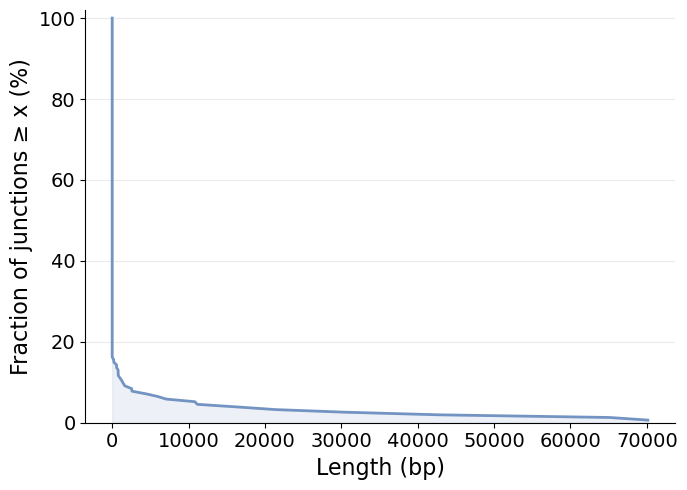

In [4]:
plot_path_comparison_lengths(path_comparison_df, histogram=False, log_x=False,
      cols=("exclusive_length",),                                                                                                                                                           
      labels=("exclusive",), figsize=(7,5), save_path="../figures/2cluster_length_distr.pdf")

## Clustering consistency with core genome phylogeny

In [ ]:
# investigate different threshold

summary_rows = []
per_cluster_parsimony_dfs = []
tree_path = "../config/polished_tree.nwk"

for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")

    per_cluster_parsimony_df = fitch_parsimony_steps_per_cluster(
        cluster_df,
        tree_path,
        junction_col="junction_name",
        save_path=f"../results/consensus_analysis/parsimonious_clusters_000{thresh}.csv"
    )
    per_cluster_parsimony_dfs.append(per_cluster_parsimony_df)

    print(per_cluster_parsimony_df.value_counts('n_parsimony_steps'))
    print(f"{len(per_cluster_parsimony_df[per_cluster_parsimony_df['n_parsimony_steps'] > 1]) / len(per_cluster_parsimony_df[per_cluster_parsimony_df['n_clusters'] > 1])} % of clusters were not consistent with the tree (excluding junctions with no clusters)")

    # only junctions with more than one cluster
    multi_cluster_df = per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].copy()
    n_clusters_not_consistent = (multi_cluster_df["n_parsimony_steps"] > 1).sum()
    bad_junctions = multi_cluster_df.loc[multi_cluster_df["n_parsimony_steps"] > 1, "junction_name"].nunique()

    # total number of clusters in junctions with > 1 cluster
    n_clusters_in_multi_cluster_junctions = len(multi_cluster_df)

    summary_rows.append({
        "threshold": float(f"0.00{thresh}"),
        "n_clusters_not_consistent_with_tree": n_clusters_not_consistent,
        "n_junctions_not_consistent_with_tree": bad_junctions,
        "n_clusters_in_junctions_with_more_than_one_cluster": n_clusters_in_multi_cluster_junctions,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("threshold").reset_index(drop=True)
print(summary_df)

Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_00005.csv
n_parsimony_steps
0     778
1     271
2      13
4       1
26      1
Name: count, dtype: int64
0.019255455712451863 % of clusters were not consistent with the tree (excluding junctions with no clusters)
Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_0001.csv
n_parsimony_steps
0    759
1    156
2     11
Name: count, dtype: int64
0.018333333333333333 % of clusters were not consistent with the tree (excluding junctions with no clusters)
Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_0002.csv
n_parsimony_steps
0    714
1    149
2     12
Name: count, dtype: int64
0.023529411764705882 % of clusters were not consistent with the tree (excluding junctions with no clusters)
Saved parsimony steps to ../results/consensus_analysis/parsimonious_clusters_0003.csv
n_parsimony_steps
0    679
1    139
2     13
Name: count, dtype: int64
0.02981651376146789 % of

In [20]:
# now we focus on the selected threshold, we find the following 10 junctions that can't be explained by one parsimonious step

jdf_all = pd.read_csv("../results/junction_summary_df.csv")

per_cluster_parsimony_dfs[1][(per_cluster_parsimony_dfs[1]['n_parsimony_steps'] >1) & ((per_cluster_parsimony_dfs[1].junction_name.isin(jdf_all.junction_name)))]

,junction_name,n_isolates,n_clusters,cluster_id,n_isolates_in_cluster,n_parsimony_steps
32,ITEMFVYTUE_r__JVDYVQZUBR_r,222,7,0,160,2
89,SFNIQHXIST_f__YSKQIEWBCG_f,222,5,0,149,2
95,SFNIQHXIST_r__TJOBMLQRFA_r,222,5,0,149,2
233,OBEJYXNUDN_r__ZTHKZYHPIX_r,222,6,0,149,2
257,OBEJYXNUDN_f__TJOBMLQRFA_f,222,6,0,149,2
442,GXPNFHPAJW_f__ZEWJRLKRRP_f,222,6,4,121,2
742,DGMGBEYIHM_r__GXPNFHPAJW_f,222,8,0,159,2
750,DGMGBEYIHM_f__JVDYVQZUBR_f,222,8,0,159,2
768,VZOKOXMBEZ_f__ZEWJRLKRRP_r,222,5,0,157,2
905,RYYAQMEJGY_r__ZTHKZYHPIX_f,216,6,0,144,2


Junctions were only NZ_JAP... differs
- SFNIQHXIST_f__YSKQIEWBCG_f: exchange --> shortening
- SFNIQHXIST_r__TJOBMLQRFA_r: exchange --> approximately the same size but gets a bit longer
- OBEJYXNUDN_r__ZTHKZYHPIX_r: exchange --> get shorter 
- OBEJYXNUDN_f__TJOBMLQRFA_f: nothing
- RYYAQMEJGY_r__ZTHKZYHPIX_f: exchange --> gets longer


In [27]:
n_junctions_with_inconsistency = len(per_cluster_parsimony_dfs[1][(per_cluster_parsimony_dfs[1]['n_parsimony_steps'] >1) & (per_cluster_parsimony_dfs[1].junction_name.isin(jdf_all.junction_name))].junction_name.unique())
print(f"{n_junctions_with_inconsistency} junctions contain 1 inconsistant cluster. These are {n_junctions_with_inconsistency / len(jdf_all) * 100} % of junctions.")

n_cluster_with_inconsistency = len(per_cluster_parsimony_dfs[1][(per_cluster_parsimony_dfs[1]['n_parsimony_steps'] >1) & (per_cluster_parsimony_dfs[1].junction_name.isin(jdf_all.junction_name))]) 
n_cluster_in_clustered_junctions = per_cluster_parsimony_dfs[1][(per_cluster_parsimony_dfs[1]['n_clusters'] > 1) & (per_cluster_parsimony_dfs[1].junction_name.isin(jdf_all.junction_name))].n_clusters.sum()
print(f"{n_cluster_with_inconsistency} cluster are not consistent with the tree. These are {n_cluster_with_inconsistency / n_cluster_in_clustered_junctions * 100} % of potentially inconsistent clusters.")

10 junctions contain 1 inconsistant cluster. These are 1.9305019305019304 % of junctions.
10 cluster are not consistent with the tree. These are 0.5159958720330238 % of potentially inconsistent clusters.


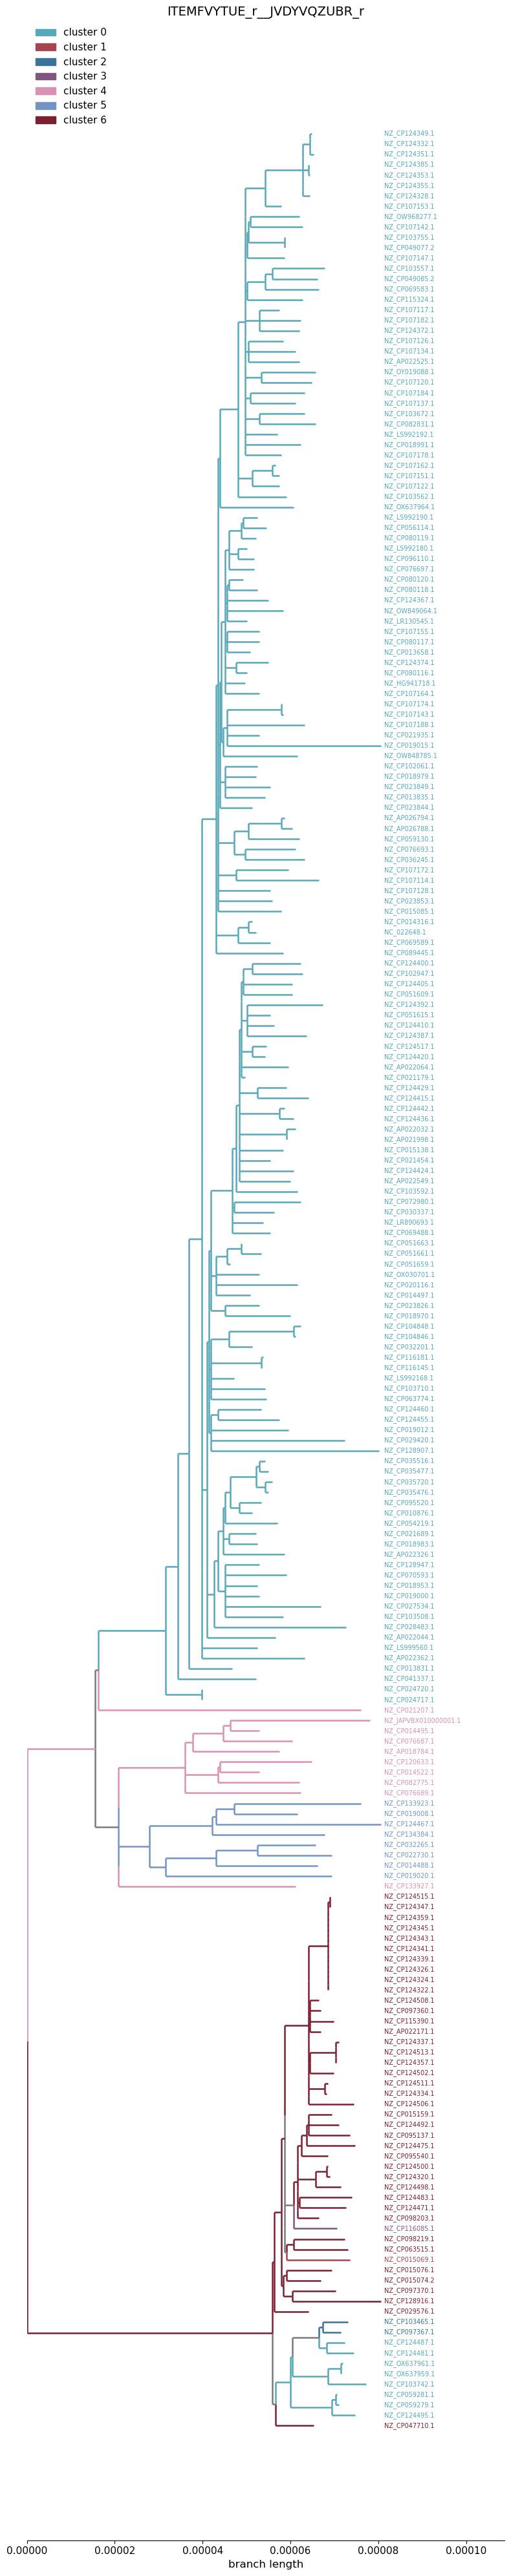

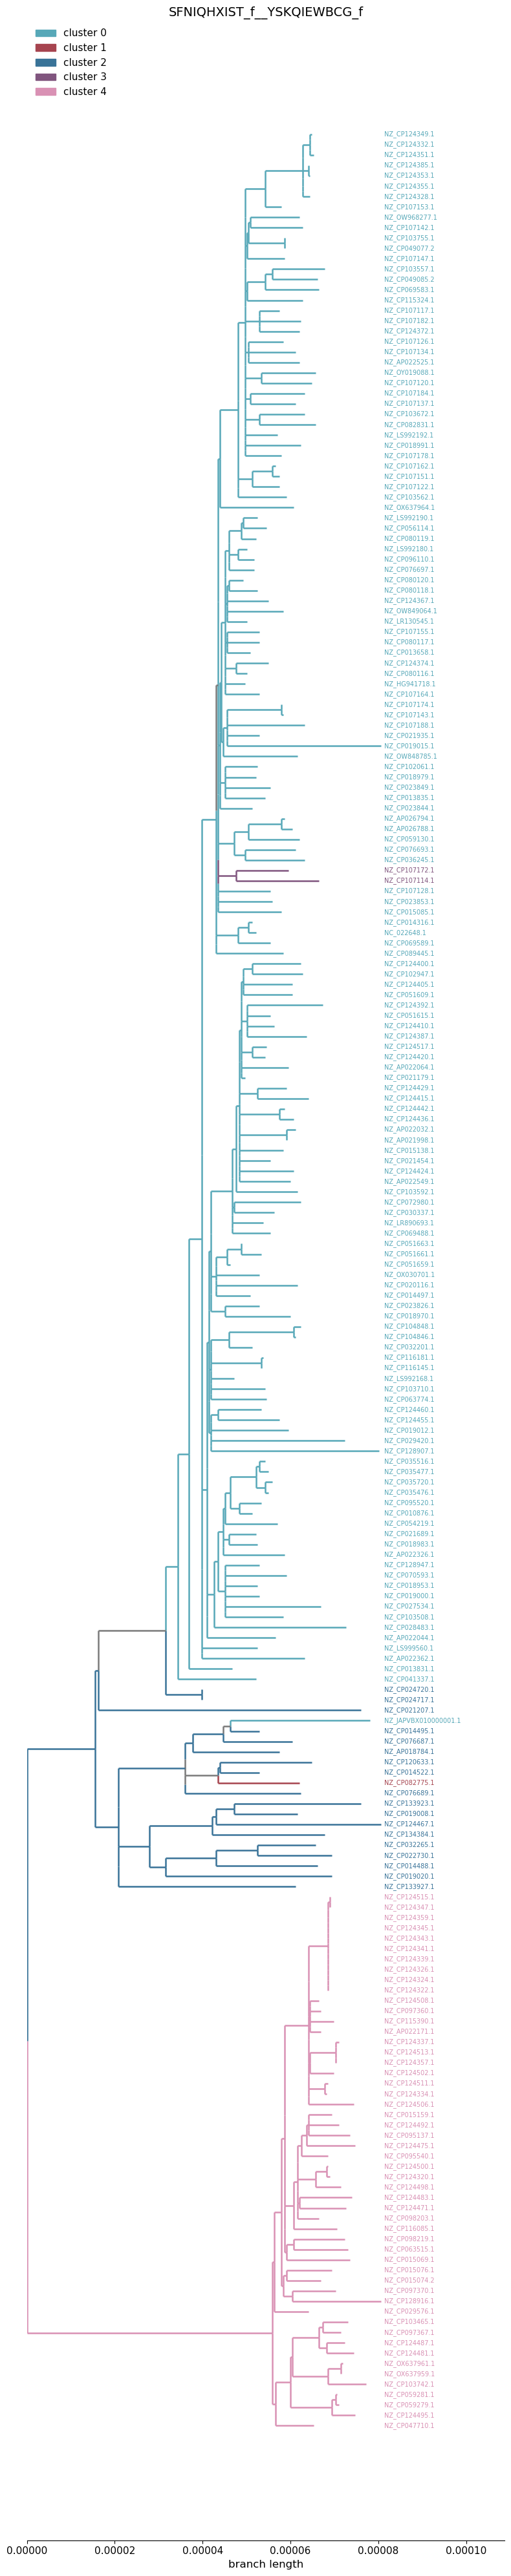

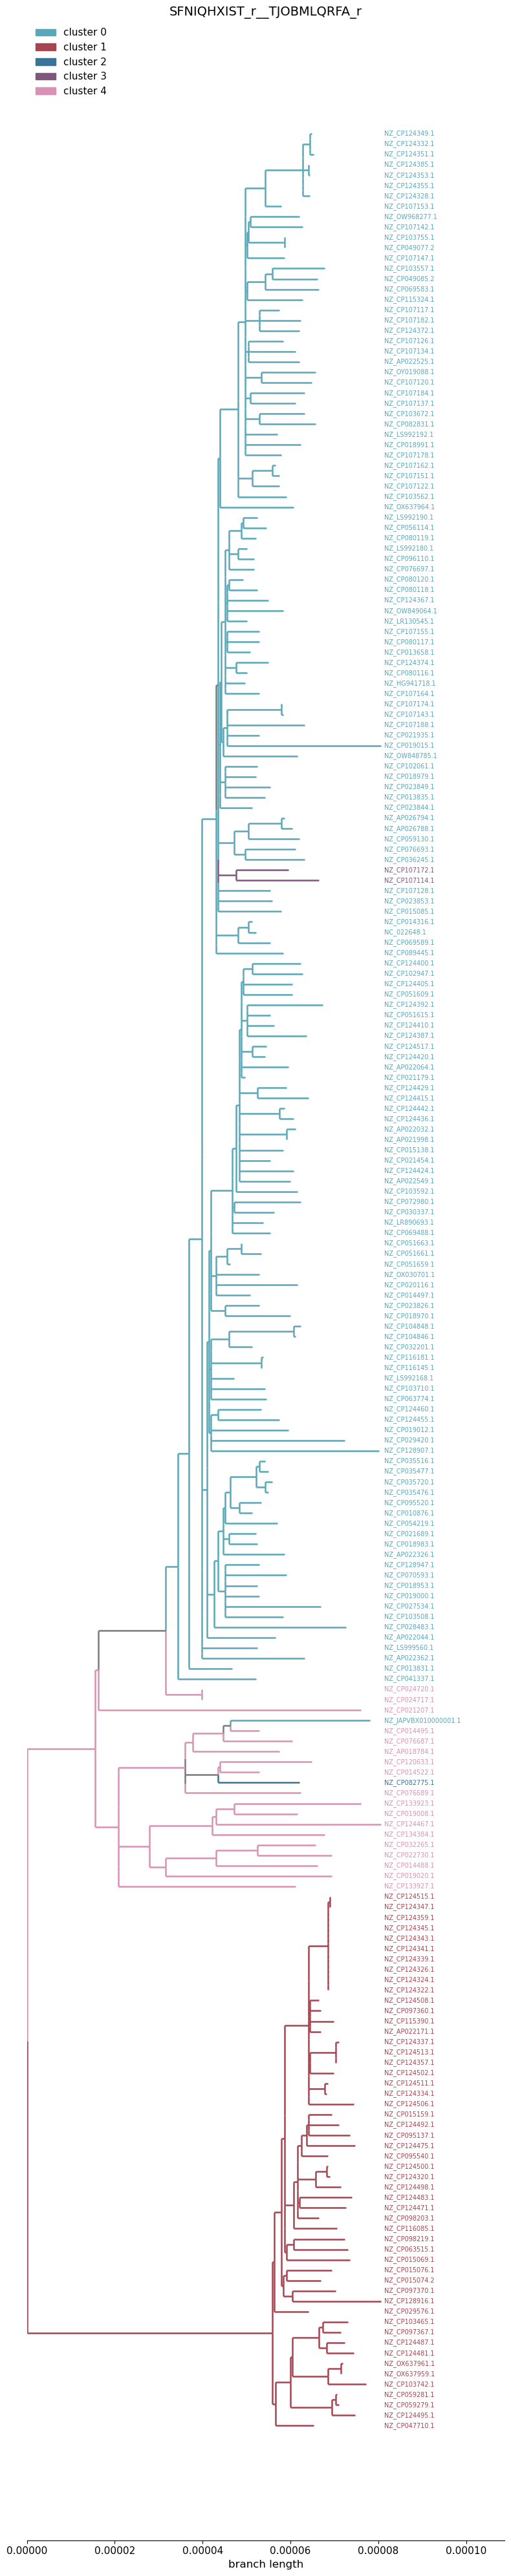

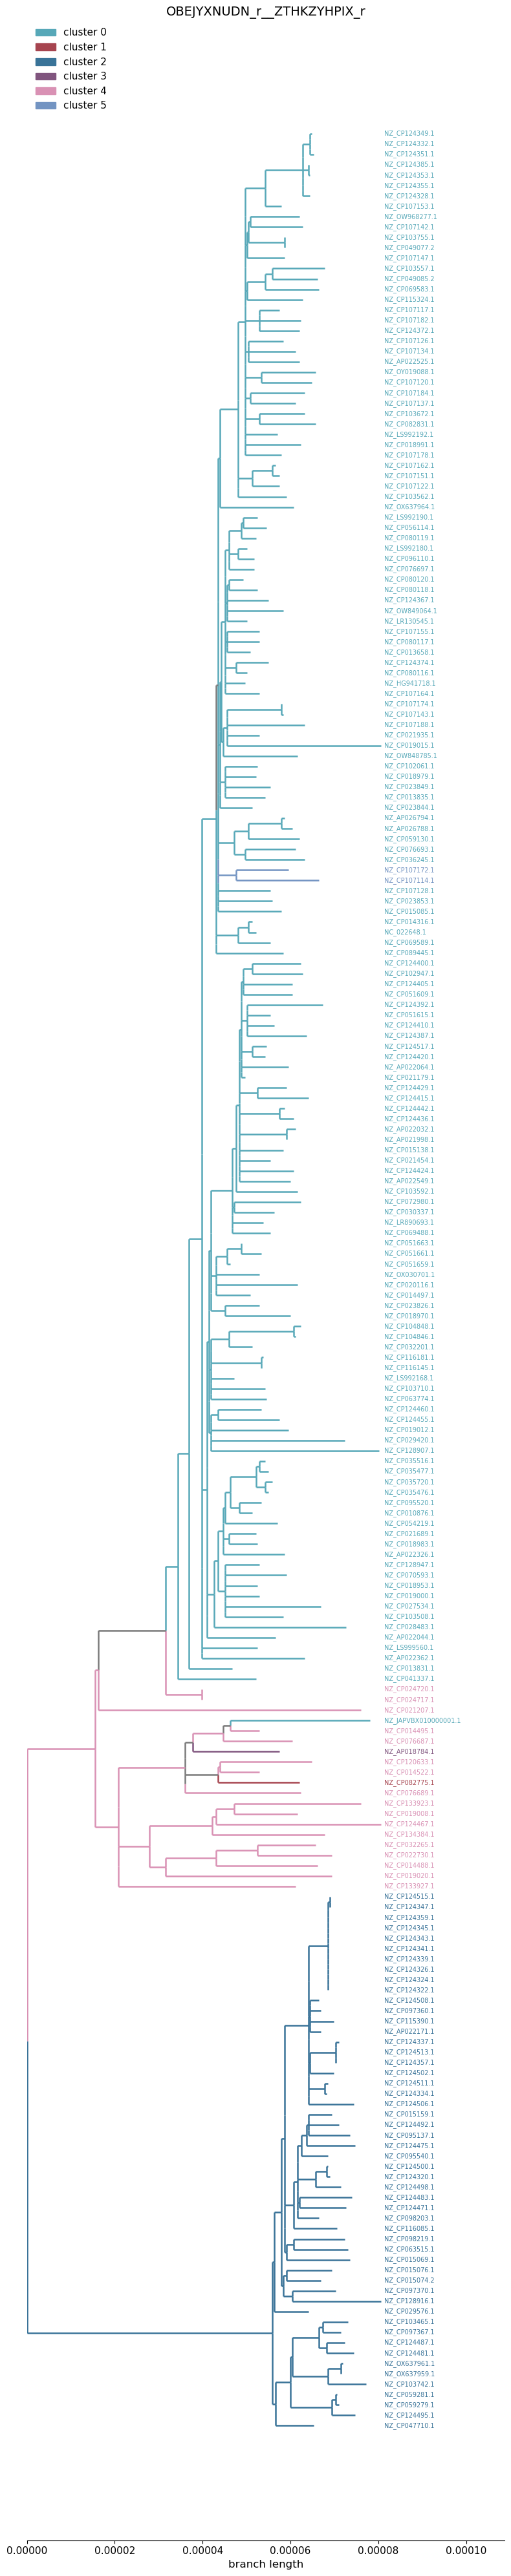

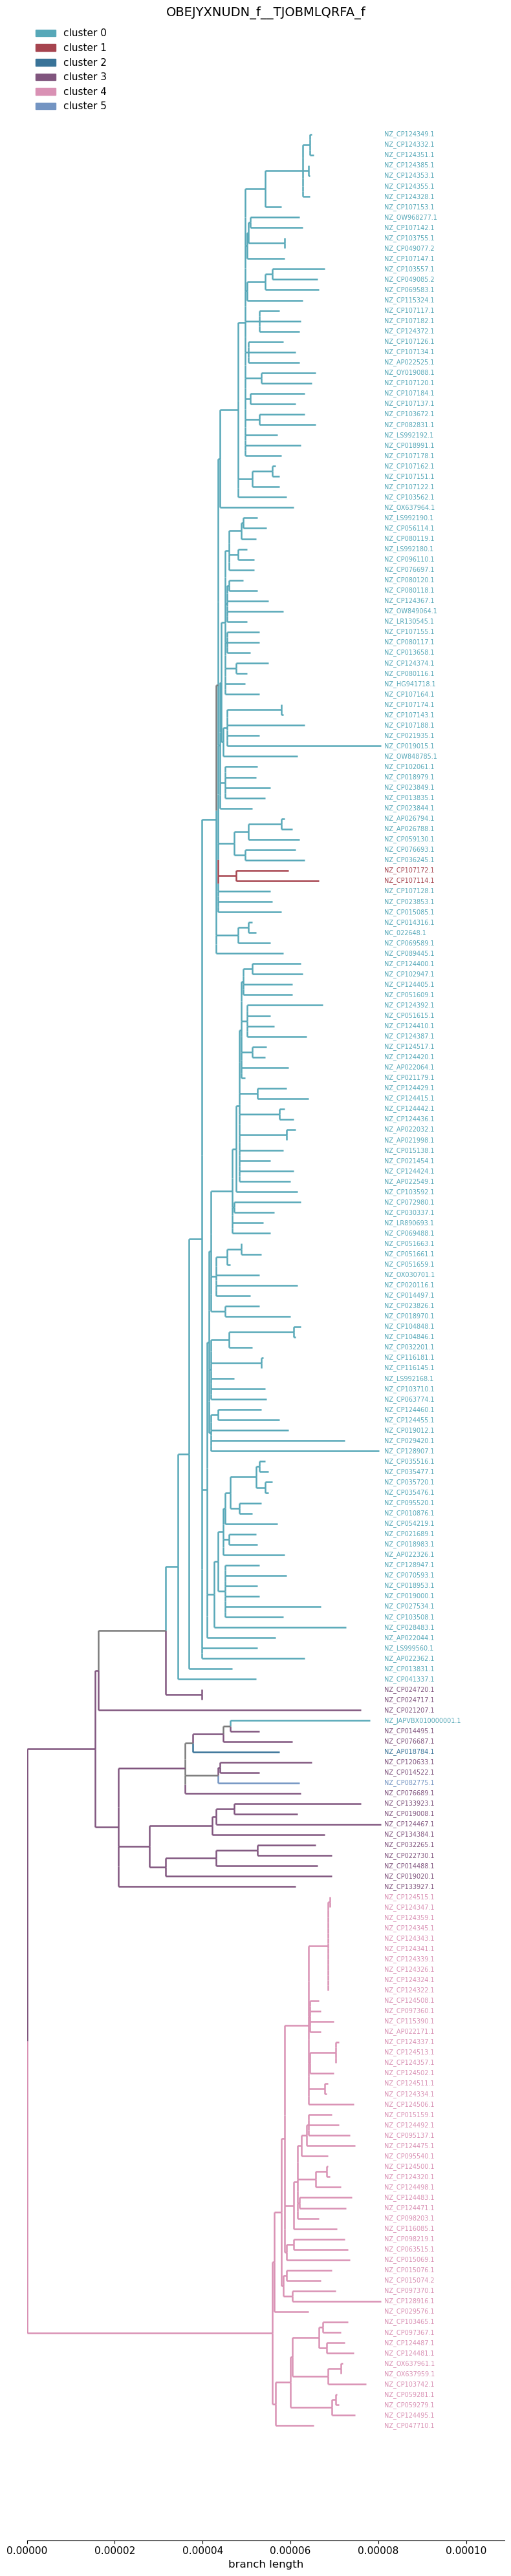

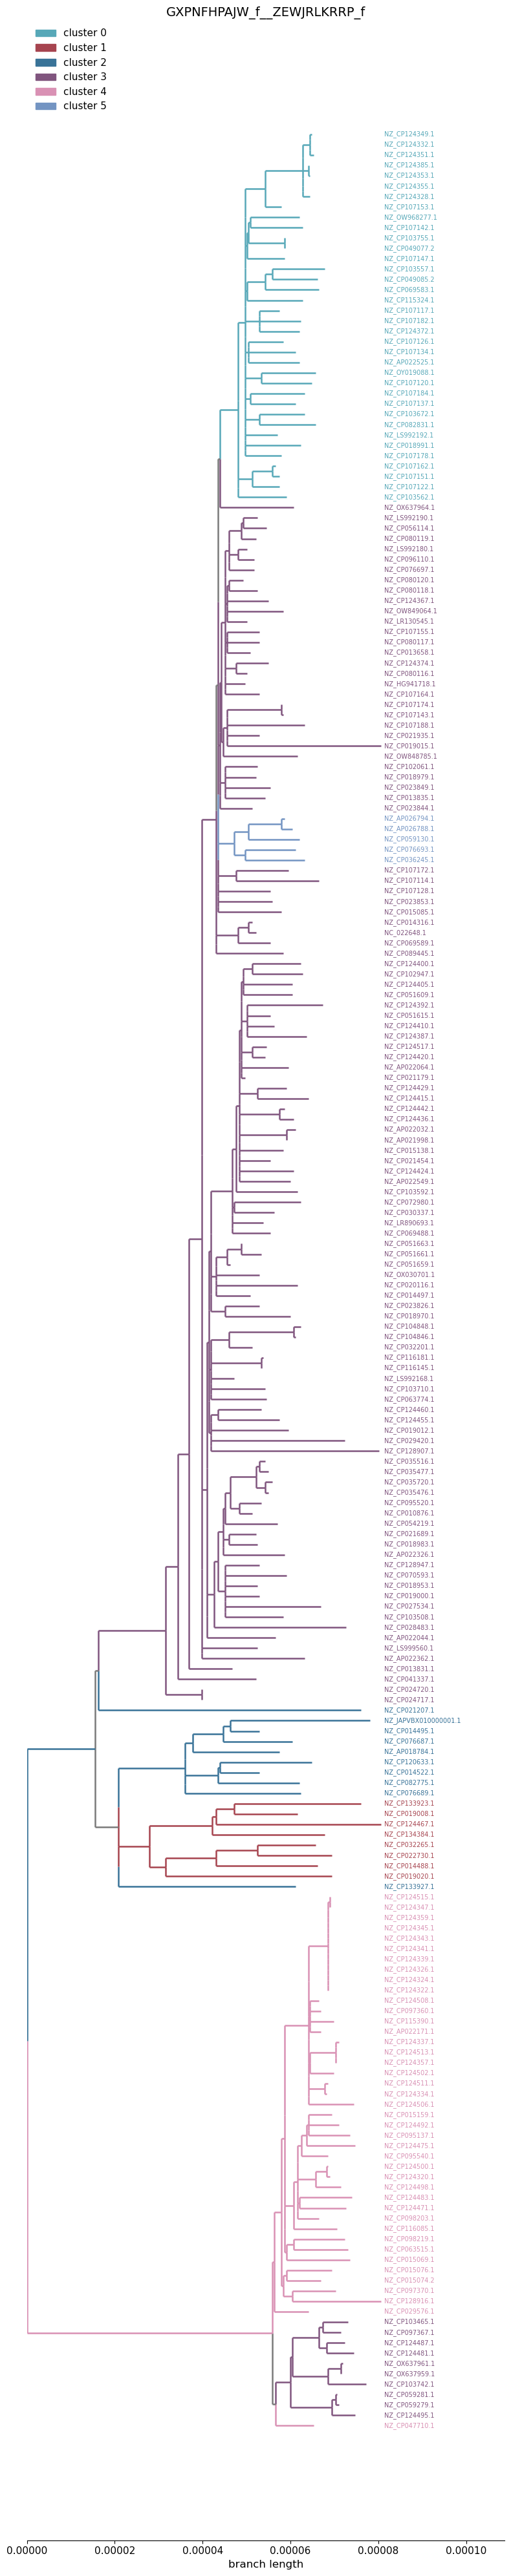

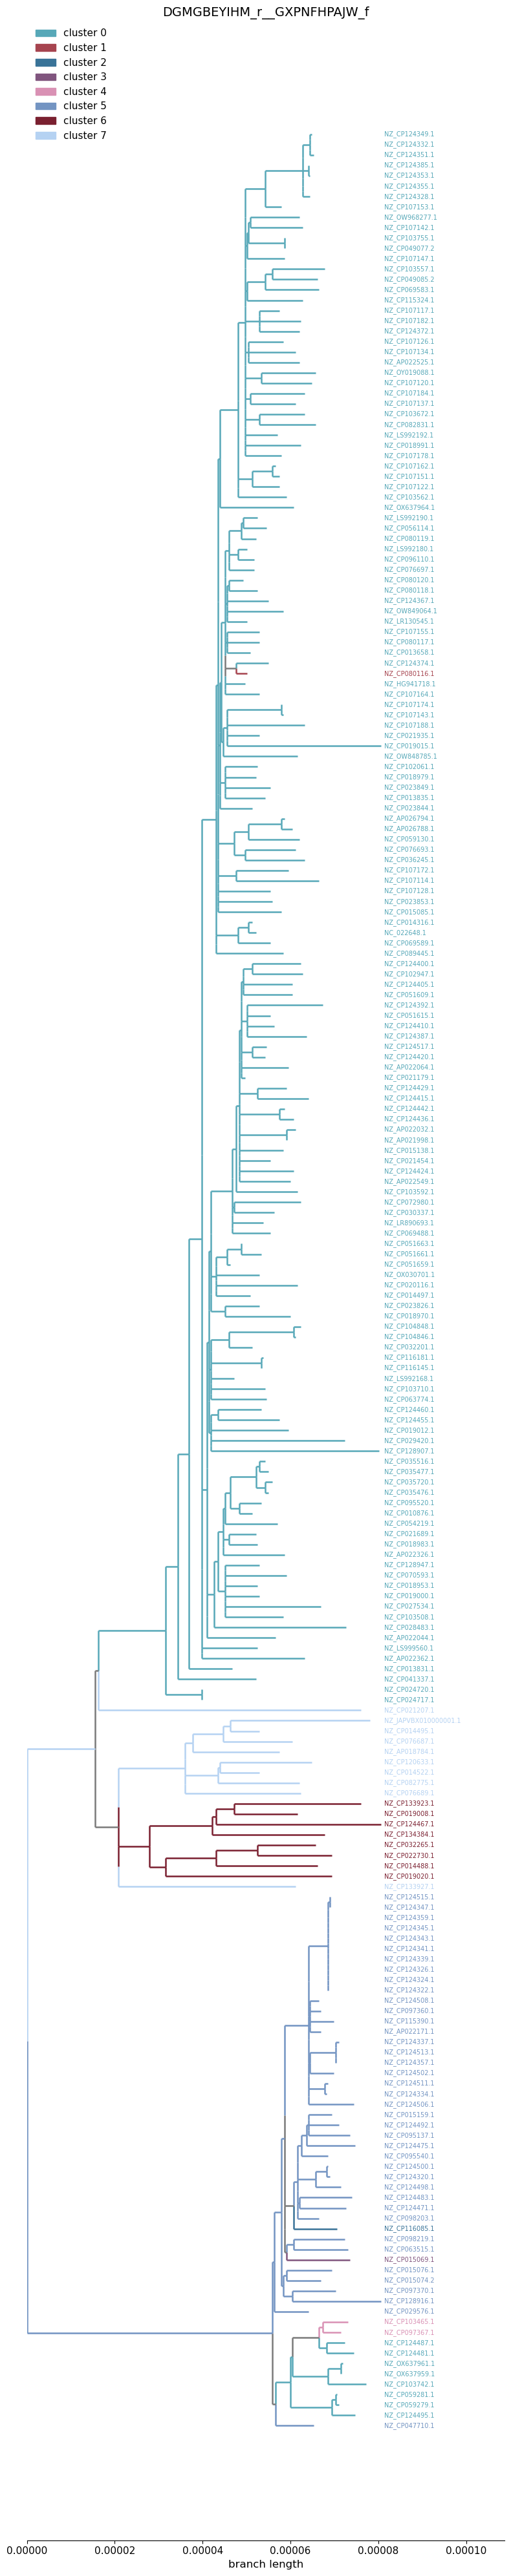

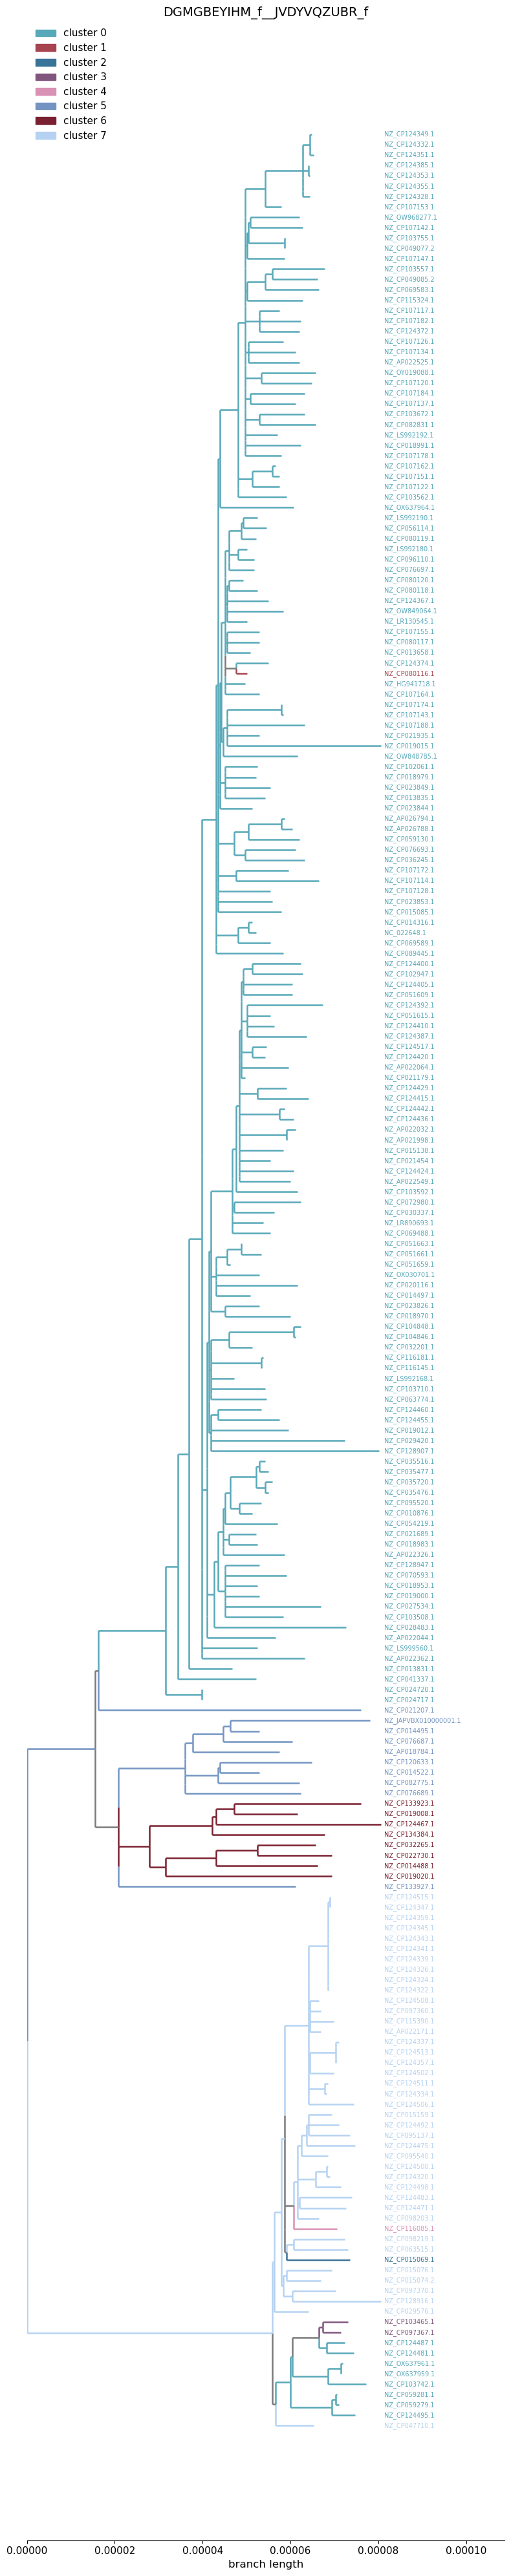

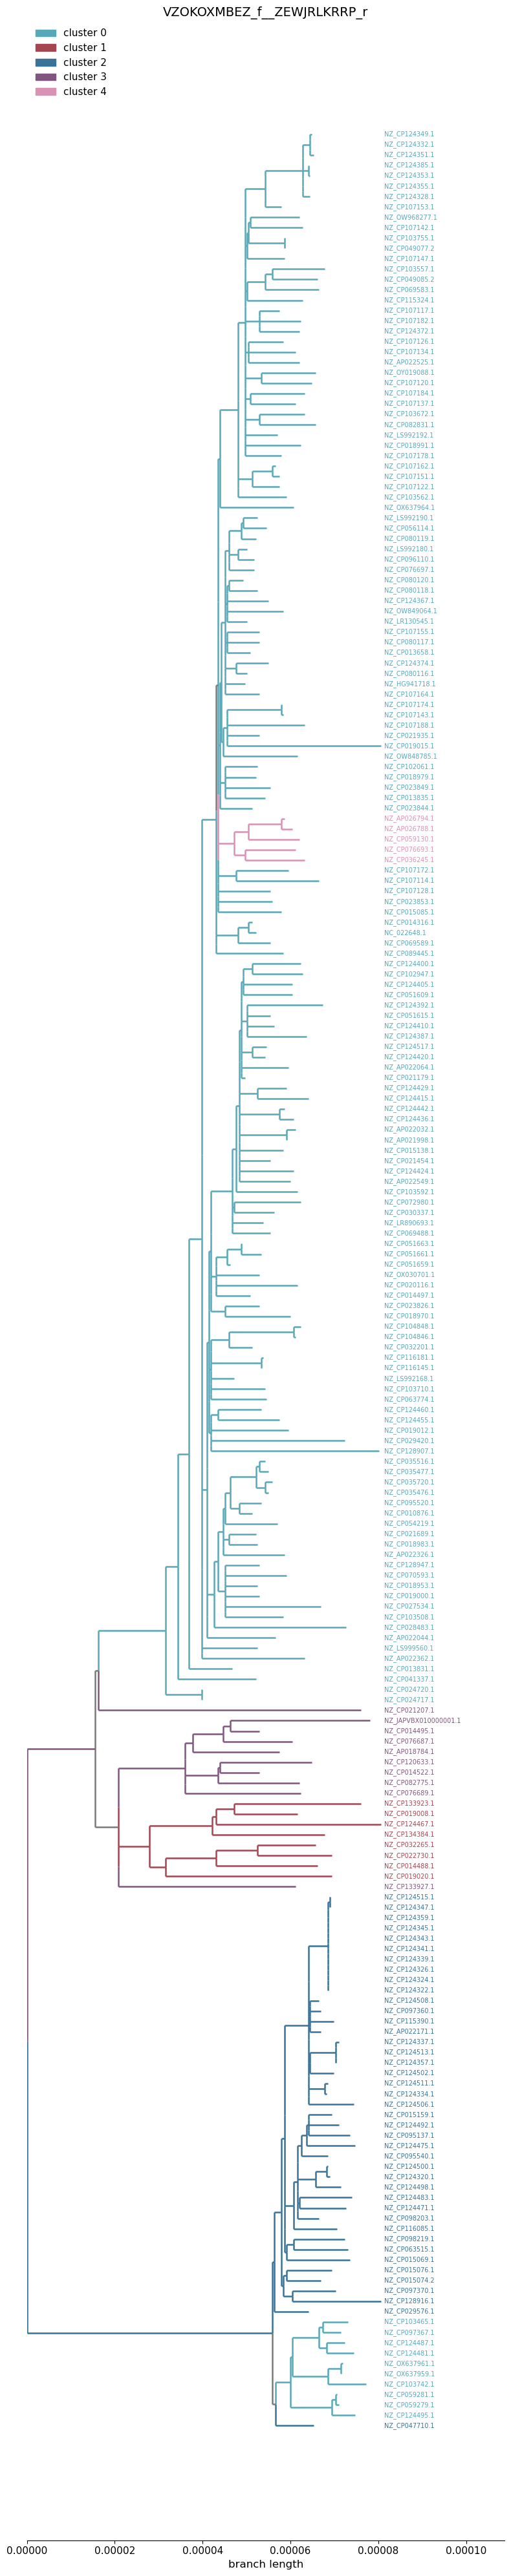

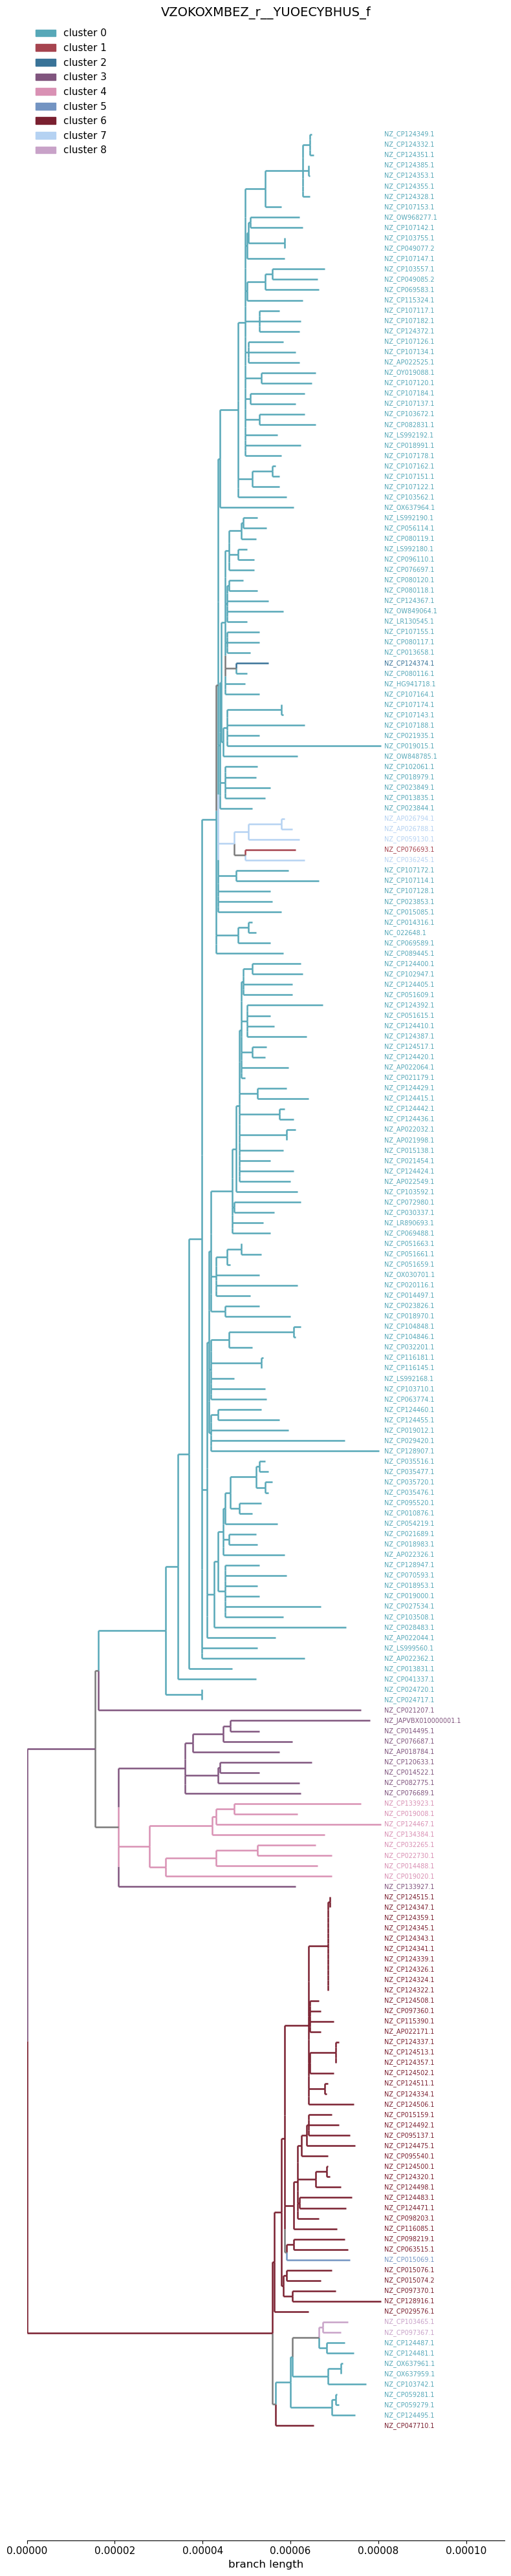

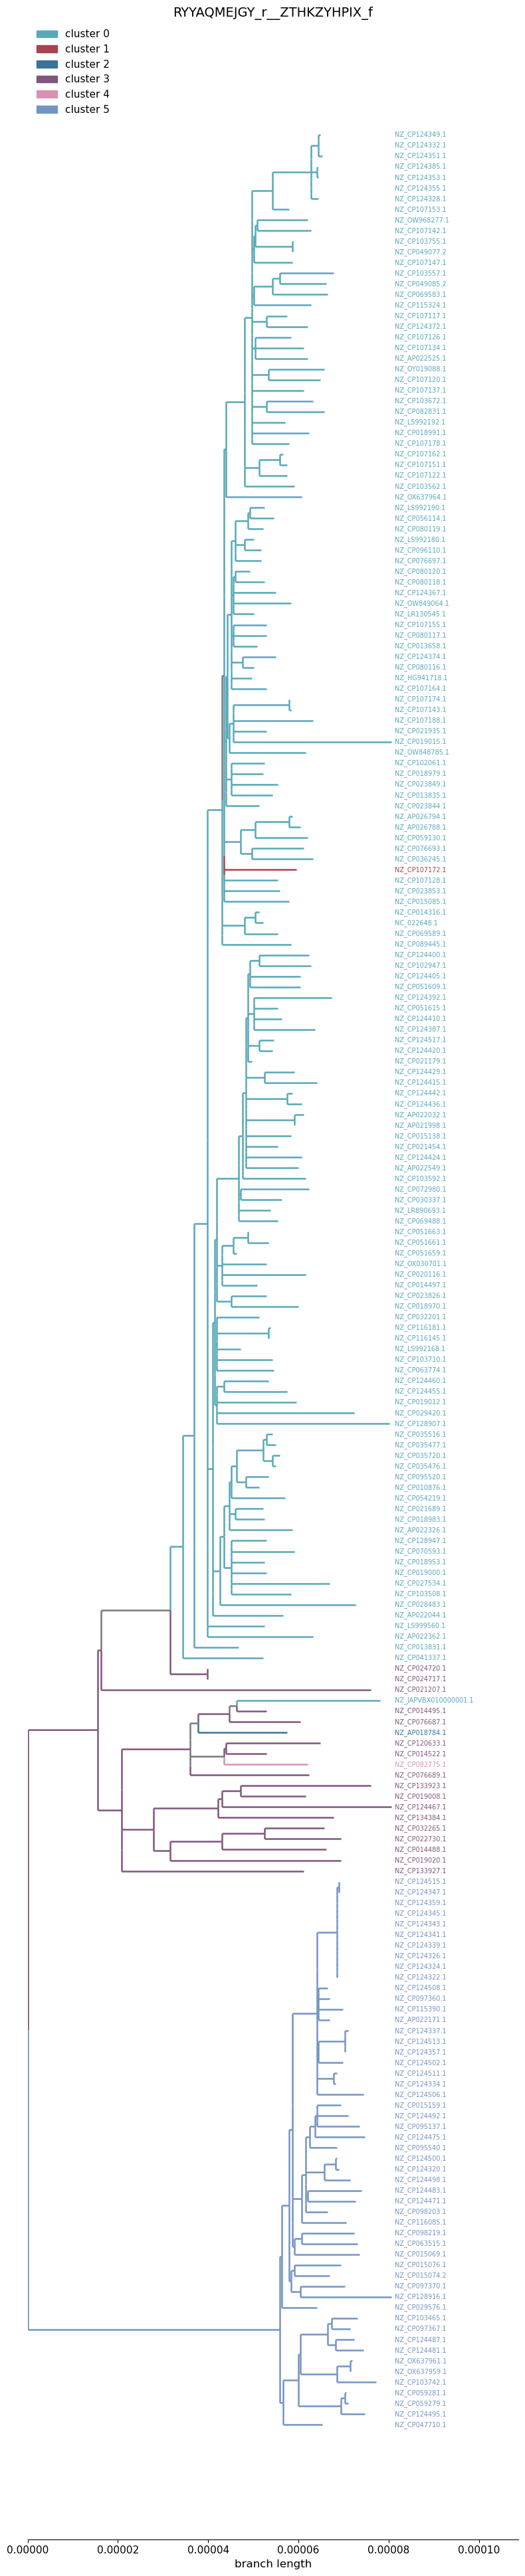

,junction_name,n_isolates,n_clusters,cluster_id,n_isolates_in_cluster,n_parsimony_steps
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,2,0,170,0
1,HUTOPWFGVH_f__WJBYSSJHSE_f,222,2,1,52,0
2,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,1,0,222,0
3,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,0,169,0
4,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,2,1,1
...,...,...,...,...,...,...
921,GPXHVRRZLC_f__KYQOKYBCOW_f,2,2,2,1,0
922,EOBHADSLFU_f__SKPHAXSFLS_r,2,1,0,2,0
923,XXIWNZXZTK_f__ZLAJFQLBFQ_r,1,1,0,1,0
924,YUOECYBHUS_f__ZTHKZYHPIX_f,2,1,0,2,0


In [28]:
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
tree_path = "../config/polished_tree.nwk"
per_cluster_parsimony_df = fitch_parsimony_steps_per_cluster(
        cluster_df,
        tree_path,
        junction_col="junction_name",
)
incompatible_junctions = per_cluster_parsimony_df[per_cluster_parsimony_df['n_parsimony_steps'] > 1].junction_name.unique().tolist()


fitch_parsimony_steps_per_cluster(cluster_df, tree_path, plot_tree=incompatible_junctions)               


## 

